--- Verifying Analytical Cosmography ---
At z = 0.5:
  dA''' | Analytical: 6727.814155773727
  dA''' | Numerical:  7048.583938740192
  Error: 320.76978296646485


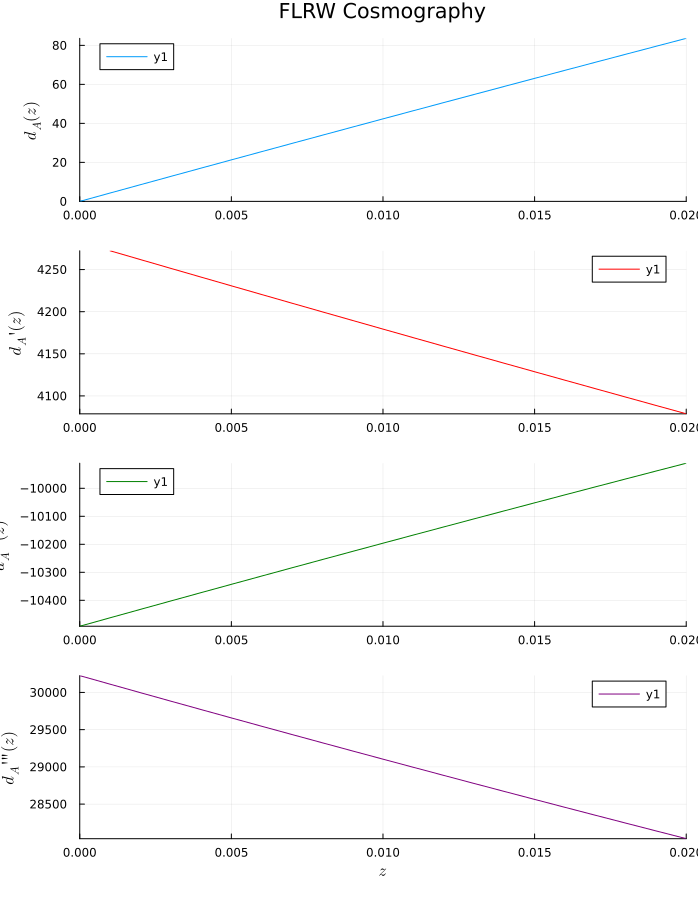

In [13]:
using ForwardDiff, QuadGK, Plots, LaTeXStrings

#=============================================================================#
# 1. Physical Constants
#=============================================================================#
const H_0 = 71.58781594e-3   
const c   = 306.5926758        
const Ω_Λ = 0.7
const Ω_m = 0.3

#=============================================================================#
# 2. The FLRW Cosmography Logic
#=============================================================================#

H_FLRW(z) = H_0 * sqrt(Ω_m * (1+z)^3 + Ω_Λ)
dHdz_FLRW(z) = (H_0^2 * 1.5 * Ω_m * (1+z)^2) / H_FLRW(z)
d2Hdz2_FLRW(z) = (3.0 * H_0^2 * Ω_m * (1+z)) / H_FLRW(z) - (dHdz_FLRW(z)^2 / H_FLRW(z))

# Distance dA(z)
function dA_FLRW(z::Real)
    z_val = Float64(z) 
    if z_val < 1e-12 return 0.0 end
    integrand(zp) = c / H_FLRW(zp)
    chi, _ = quadgk(integrand, 0.0, z_val)
    return chi / (1.0 + z_val)
end

# Analytical First Derivative
function ddA_dz_ana(z)
    da = dA_FLRW(z)
    return (1/(1+z)) * (c/H_FLRW(z) - da)
end

# Analytical Second Derivative
function d2dA_dz2_ana(z)
    h   = H_FLRW(z)
    hp  = dHdz_FLRW(z)
    da  = dA_FLRW(z)
    dap = ddA_dz_ana(z)
    
    term1 = - (1/(1+z)^2) * (c/h - da)
    term2 = (1/(1+z)) * (-c*hp/h^2 - dap)
    return term1 + term2
end

# Analytical Third Derivative
function d3dA_dz3_ana(z)
    h    = H_FLRW(z)
    hp   = dHdz_FLRW(z)
    hpp  = d2Hdz2_FLRW(z)
    da   = dA_FLRW(z)
    dap  = ddA_dz_ana(z)
    dapp = d2dA_dz2_ana(z)
    
    # Derivative of the first bracket term: -1/(1+z)^2 * (c/h - da)
    d_term1 = 2/(1+z)^3 * (c/h - da) - 1/(1+z)^2 * (-c*hp/h^2 - dap)
    
    # Derivative of the second bracket term: 1/(1+z) * (-c*hp/h^2 - dap)
    # let f = -c*hp/h^2 - dap
    f = -c*hp/h^2 - dap
    df = -c*(hpp/h^2 - 2*hp^2/h^3) - dapp
    d_term2 = -1/(1+z)^2 * f + 1/(1+z) * df
    
    return d_term1 + d_term2
end

#=============================================================================#
# 3. Robust Verification
#=============================================================================#

function run_cosmo_verification()
    println("--- Verifying Analytical Cosmography ---")
    
    z_test = 0.5
    h = 1e-5
    
    # Central difference for 3rd derivative
    f_ppp = (dA_FLRW(z_test + 2h) - 2*dA_FLRW(z_test + h) + 2*dA_FLRW(z_test - h) - dA_FLRW(z_test - 2h)) / (2 * h^3)
    
    ana_ppp = d3dA_dz3_ana(z_test)
    
    println("At z = $z_test:")
    println("  dA''' | Analytical: $ana_ppp")
    println("  dA''' | Numerical:  $f_ppp")
    println("  Error: $(abs(ana_ppp - f_ppp))")

    # Plotting
    zs = 0.0:0.001:0.02
    p1 = plot(zs, dA_FLRW.(zs), ylabel=L"d_A(z)", title="FLRW Cosmography")
    p2 = plot(zs, ddA_dz_ana.(zs), ylabel=L"d_A'(z)", color=:red)
    p3 = plot(zs, d2dA_dz2_ana.(zs), ylabel=L"d_A''(z)", color=:green)
    p4 = plot(zs, d3dA_dz3_ana.(zs), ylabel=L"d_A'''(z)", xlabel=L"z", color=:purple)
    
    # Set limits for small z as requested
    xlims!(p1, 0, 0.02); ylims!(p1, dA_FLRW(0.0), dA_FLRW(0.02))
    xlims!(p2, 0, 0.02); ylims!(p2, ddA_dz_ana(0.02), ddA_dz_ana(0.001))
    xlims!(p3, 0, 0.02); ylims!(p3, d2dA_dz2_ana(0.0), d2dA_dz2_ana(0.02))
    xlims!(p4, 0, 0.02); ylims!(p4, d3dA_dz3_ana(0.02), d3dA_dz3_ana(0.00))

    display(plot(p1, p2, p3, p4, layout=(4,1), size=(700,900)))
end

run_cosmo_verification()

In [ ]:
# =============================================================================
# Imports
# =============================================================================
using NPZ
using Plots
using Plots.Measures # Required for margin adjustments
using PGFPlotsX      # Native PGF/LaTeX rendering
using LaTeXStrings
using PlotUtils

# =============================================================================
# Configuration
# =============================================================================
const DATA_DIR = "data/pixels_diov"
const BASE_PLOT_DIR = "plots_diov"

isdir(BASE_PLOT_DIR) || mkdir(BASE_PLOT_DIR)

# PGFPlotsX & Plots.jl Setup 
pgfplotsx() 
push!(PGFPlotsX.CUSTOM_PREAMBLE, "\\usepackage{amsmath}")

Plots.default(
    fontfamily = "Computer Modern",
    titlefont  = font(10, "Computer Modern"), 
    guidefont  = font(10, "Computer Modern"), 
    tickfont   = font(8, "Computer Modern"), 
    legendfont = font(8, "Computer Modern"), 
    size       = (320, 375),  
    linewidth  = 1,         
    legend     = :topleft     
)

# Color Palette Setup
tol_colors = PlotUtils.palette(:tol_bright)
line_colors = [tol_colors[1], tol_colors[2], tol_colors[3], tol_colors[5], tol_colors[4]]

# =============================================================================
# Utility Functions
# =============================================================================
function dA_exp(z, z_range, dA, dA_z, dA_zz, dA_zzz)
    z_eval = round(Int, z * 1e5 + 1)
    dz = z_range .- z
    return @. dA[z_eval] + dA_z[z_eval] * dz + 0.5 * dA_zz[z_eval] * dz^2 + (1/6) * dA_zzz[z_eval] * dz^3
end

function pgf_safe(y; limit=1000.0)
    return clamp.(y, -limit, limit)
end

# =============================================================================
# Minimal Data Loading 
# =============================================================================
println("Loading data for target pixel...")
# Instead of loading all NPIX maps into memory, we just load pixel 1000 directly.
# (If you don't have pixel 1000 saved independently, change this to pixel 1)
data         = npzread(joinpath(DATA_DIR, "dA_pixel_1000.npz"))
z_range      = data["z_range"]
dA_exact     = data["dA"]
dA_z_exact   = data["dA_z"]
dA_zz_exact  = data["dA_zz"]
dA_zzz_exact = data["dA_zzz"]

# =============================================================================
# Plot Generation
# =============================================================================
println("Generating combined plot...")

# --- Top Plot ---
p1 = Plots.plot(z_range, pgf_safe(dA_exact), label="Exact", color=line_colors[1], legend=:bottomright)
Plots.plot!(p1, z_range, pgf_safe(dA_exp(0.000, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact)), label=L"z_*=0.000", ls=:dash, color=line_colors[2])
Plots.plot!(p1, z_range, pgf_safe(dA_exp(0.002, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact)), label=L"z_*=0.002", ls=:dot, color=line_colors[3])
Plots.plot!(p1, z_range, pgf_safe(dA_exp(0.004, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact)), label=L"z_*=0.004", ls=:dashdot, color=line_colors[4])
Plots.plot!(p1, z_range, pgf_safe(dA_exp(0.006, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact)), label=L"z_*=0.006", ls=:dashdotdot, color=line_colors[5])
Plots.ylabel!(p1, L"d_A")
Plots.title!(p1, L"d_A \text{ exact vs expansion (fiducial ray, LTB2)}")
Plots.xlims!(p1, 0, 0.008)
Plots.ylims!(p1, 0, 34)

# Remove x-ticks and reduce bottom margin to pull the plots together
Plots.plot!(p1, xlabel="", xticks=:none, bottom_margin=-5mm)


# --- Bottom Plot ---
dA_exact_safe = copy(dA_exact)
dA_exact_safe[dA_exact_safe .== 0] .= 1e-10 

p2 = Plots.plot(z_range, pgf_safe(dA_exact ./ dA_exact_safe, limit=100.0), label="Exact", color=line_colors[1], legend=:none)
Plots.plot!(p2, z_range, pgf_safe(dA_exp(0.000, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact) ./ dA_exact_safe, limit=100.0), label=L"z_*=0.000", ls=:dash, color=line_colors[2])
Plots.plot!(p2, z_range, pgf_safe(dA_exp(0.002, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact) ./ dA_exact_safe, limit=100.0), label=L"z_*=0.002", ls=:dot, color=line_colors[3])
Plots.plot!(p2, z_range, pgf_safe(dA_exp(0.004, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact) ./ dA_exact_safe, limit=100.0), label=L"z_*=0.004", ls=:dashdot, color=line_colors[4])
Plots.plot!(p2, z_range, pgf_safe(dA_exp(0.006, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact) ./ dA_exact_safe, limit=100.0), label=L"z_*=0.006", ls=:dashdotdot, color=line_colors[5])
Plots.xlabel!(p2, L"z")
Plots.ylabel!(p2, L"d_A/d_{A,\mathrm{exact}}")
Plots.xlims!(p2, 0, 0.008)
Plots.ylims!(p2, -1, 3)

# Reduce top margin to meet the top plot
Plots.plot!(p2, top_margin=-5mm)


# --- Combine and Save ---
p_combined = Plots.plot(p1, p2, 
    layout = grid(2, 1, heights=[2/3, 1/3]),
    link = :x 
)

Plots.savefig(p_combined, joinpath(BASE_PLOT_DIR, "fiducial_ray_combined.pdf"))
Plots.savefig(p_combined, joinpath(BASE_PLOT_DIR, "fiducial_ray_combined.tex"))

println("Done! Plot saved to $(BASE_PLOT_DIR)/fiducial_ray_combined.pdf")

Loading data for target pixel...
Generating combined plot...
Done! Plot saved to plots_diov/fiducial_ray_combined.pdf
